In [9]:
import numpy as np
import SUITPy as suit
import cortico_cereb_connectivity.globals as gl
import cortico_cereb_connectivity.summarize as css
import Functional_Fusion.atlas_map as am
import matplotlib.pyplot as plt
import seaborn as sns

#### Load the models

In [ ]:
# cortex model
model, _ = css.get_model(traindata=gl.traindata_string(),
                            cortex_roi='Icosahedron1002',
                            method='L2reg',
                            extension='A2_global',
                            norm=True)

# model with hippocampus
model_h, _ = css.get_model(traindata=gl.traindata_string(),
                            cortex_roi='Icosahedron1002-MNIAsymHippocampus',
                            method='L2reg',
                            extension='A2_global',
                            norm=True)

In [ ]:
cereb_atlas, _ = am.get_atlas('MNISymC3')
# last 10 parcels of model belong to Hippocamp with the order as "names"
names = ['1L', '2L', '3L', '4L', '5L', '1R', '2R', '3R', '4R', '5R']
w_hipp = model_h.coef_[:,-10:]
maxw = np.abs(np.max(w_hipp))

#### Plot each region weights

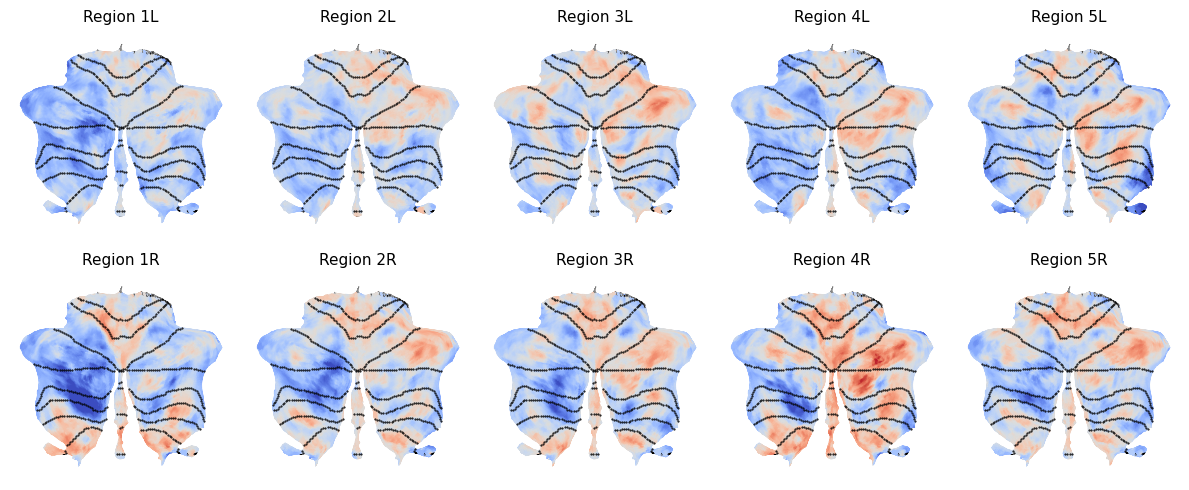

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, name in enumerate(names):
    w_vec = w_hipp[:, i]
    nifti_image = cereb_atlas.data_to_nifti(w_vec)
    data = suit.vol_to_surf(nifti_image, space='MNISymC')

    plt.subplot(2, 5, i+1)
    suit.flatmap.plot(data, cmap='coolwarm', new_figure=False, cscale=[-maxw*0.7, maxw*0.7], bordersize=1)
    plt.title(f'Region {name}', fontsize=11)

plt.tight_layout();

#### Plot left and right averages

In [ ]:
w_left = np.mean(w_hipp[:, :5], axis=1)
w_right = np.mean(w_hipp[:, 5:], axis=1)
maxw = np.abs(np.max([w_left, w_right]))

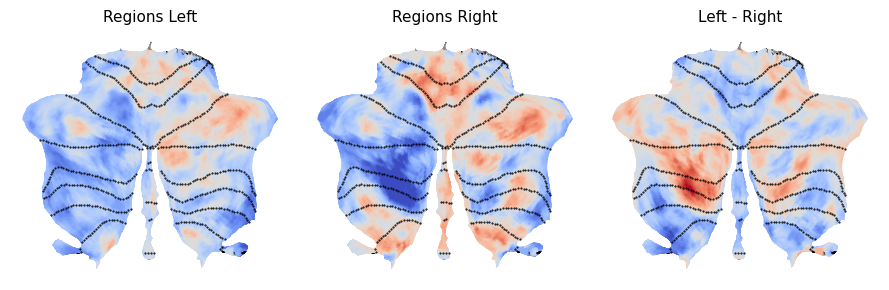

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3))

for i, (w_vec, side) in enumerate(zip([w_left, w_right], ['Left', 'Right'])):
    nifti_image = cereb_atlas.data_to_nifti(w_vec)
    data = suit.vol_to_surf(nifti_image, space='MNISymC')

    plt.subplot(1, 3, i+1)
    suit.flatmap.plot(data, cmap='coolwarm', new_figure=False, cscale=[-maxw*0.7, maxw*0.7], bordersize=1)
    plt.title(f'Regions {side}', fontsize=11)

# the difference
nifti_image = cereb_atlas.data_to_nifti(w_left - w_right)
data = suit.vol_to_surf(nifti_image, space='MNISymC')
plt.subplot(1, 3, 3)
suit.flatmap.plot(data, cmap='coolwarm', new_figure=False, cscale=[-maxw*0.7, maxw*0.7], bordersize=1)
plt.title(f'Left - Right', fontsize=11)

plt.tight_layout();